# SQL Sales Analysis using Olist Brazilian E-Commerce Dataset

## 1. 프로젝트 개요 (Project Overview)

본 프로젝트는 Olist Brazilian E-Commerce 데이터를 활용하여 SQL 기반의 데이터 분석을 수행하였다.

관계형 데이터베이스의 구조를 이해하고, 주문(Order), 고객(Customer), 상품(Product), 배송(Delivery) 데이터를 분석하여 비즈니스 인사이트를 도출하는 것을 목표로 한다.

또한 SQL의 JOIN, GROUP BY, CASE WHEN, Subquery 등을 활용하여 실제 데이터 분석 프로젝트를 수행하였다.

## 2. 데이터셋 소개 (Dataset Overview)

Olist Brazilian E-Commerce Dataset은 브라질 전자상거래 플랫폼의 주문, 고객, 상품, 결제, 배송 등의 데이터를 포함한 관계형 데이터셋이다.

이번 프로젝트에서는 Orders, Customers, Order Items, Products 테이블을 중심으로 분석을 진행한다.

## 3. 데이터 불러오기 (Data Loading)

In [33]:
import pandas as pd
import sqlite3

DATA_PATH = "../data"

orders = pd.read_csv(f"{DATA_PATH}/olist_orders_dataset.csv")
customers = pd.read_csv(f"{DATA_PATH}/olist_customers_dataset.csv")
order_items = pd.read_csv(f"{DATA_PATH}/olist_order_items_dataset.csv")
products = pd.read_csv(f"{DATA_PATH}/olist_products_dataset.csv")

## 4. 데이터 이해 (Data Understanding)

### 4.1 Orders Table 이해

In [36]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [37]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [38]:
orders.shape

(99441, 8)

### Orders 테이블 분석 (Order Table Analysis)

#### 기본 정보
- Orders 테이블은 총 **8개의 컬럼(Column)** 과 **99,441개의 주문(Row)** 으로 구성되어 있다.
- 주문 ID, 고객 ID, 주문 상태, 주문 시각, 배송 관련 정보를 포함하고 있다.

#### 데이터 타입
- 날짜 관련 컬럼이 모두 `object` 타입으로 저장되어 있다.
- 추후 날짜 기반 분석을 위해 `datetime` 타입으로 변환할 예정이다.

#### 테이블 역할
- Orders 테이블은 주문 정보를 저장하는 핵심 테이블이다.

### 4.2 Customers Table 이해

In [41]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [42]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [43]:
customers.shape

(99441, 5)

### Customers 테이블 분석 (Customer Table Analysis)

#### 기본 정보
- Customers 테이블은 총 **5개의 컬럼(Column)** 과 **99,441개의 고객(Row)** 으로 구성되어 있다.
- 고객 ID, 고객 고유 ID, 지역 정보를 포함하고 있다.

#### 데이터 타입
- 문자열(object)과 정수형(int64) 컬럼으로 구성되어 있다.
- 고객 식별 정보와 지역 정보를 저장하고 있다.

#### 테이블 역할
- Customers 테이블은 고객 식별 정보와 지역 정보를 저장하는 테이블이다.
- `customer_id` 컬럼을 이용하여 Orders 테이블과 연결할 수 있다.
- `customer_id`와 `customer_unique_id`의 차이를 추가적으로 확인할 예정이다.

### 4.3 Order Item Table 이해

In [46]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [47]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [48]:
order_items.shape

(112650, 7)

### Order Items 테이블 분석 (Order Items Table Analysis)

#### 기본 정보
- Order Items 테이블은 총 **7개의 컬럼(Column)** 과 **112,650개의 주문 상품(Row)** 으로 구성되어 있다.
- 주문, 상품, 판매자, 배송 및 가격 정보를 포함하고 있다.

#### 데이터 타입
- 문자열(object), 정수형(int64), 실수형(float64) 컬럼으로 구성되어 있다.
- 주문, 상품, 판매자 ID와 배송 및 가격 정보를 저장하고 있다.

#### 테이블 역할
- Order Items 테이블은 주문에 포함된 상품 정보를 저장하는 테이블이다.
- `order_id` 컬럼을 이용하여 Orders 테이블과 연결할 수 있다.

### 4.4 Products Table 이해

In [51]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [52]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [53]:
products.shape

(32951, 9)

### Products 테이블 분석 (Products Table Analysis)

#### 기본 정보
- Products 테이블은 총 **9개의 컬럼(Column)** 과 **32,951개의 상품(Row)** 으로 구성되어 있다.
- 상품 ID, 상품 카테고리, 상품명 길이, 상품 설명 길이, 사진 개수, 무게 및 크기 정보를 포함하고 있다.

#### 데이터 타입
- 문자열(object)과 실수형(float64) 컬럼으로 구성되어 있다.
- 상품의 카테고리, 크기, 무게 등 상품의 상세 정보를 저장하고 있다.

#### 테이블 역할
- Products 테이블은 상품에 대한 정보를 저장하는 테이블이다.
- `product_id` 컬럼을 이용하여 Order Items 테이블과 연결할 수 있다.

## 5. 데이터 품질 확인 (Data Quality Check)

테이블들의 데이터 품질을 확인하기 위해 결측치, 중복 데이터, 주문 상태, 데이터 기간을 확인하였다.

In [56]:
# 5.1 결측치 확인 (Missing Values)
print("===== Missing Values =====")
print("\n---Orders Table---")
print(orders.isnull().sum())
print("\n---Customers Table---")
print(customers.isnull().sum())
print("\n---Order Items Table---")
print(order_items.isnull().sum())
print("\n---Products Table---")
print(products.isnull().sum())

===== Missing Values =====

---Orders Table---
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

---Customers Table---
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

---Order Items Table---
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

---Products Table---
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_len

In [57]:
# 5.2 Primary Key 중복 확인 (Duplicate PK Check)
print("\n===== Duplicate PK Check =====")
print("Orders Table:", orders["order_id"].duplicated().sum())

print("Customers Table:", customers["customer_id"].duplicated().sum())

print("Order Items Table:", order_items[["order_id","order_item_id"]].duplicated().sum())

print("Products Table:", products["product_id"].duplicated().sum())


===== Duplicate PK Check =====
Orders Table: 0
Customers Table: 0
Order Items Table: 0
Products Table: 0


In [58]:
# 5.3 주문 상태 확인 (Order Status)
print("\n===== Order Status =====")
print(orders["order_status"].value_counts())

# 5.4 데이터 기간 확인 (Order Date Range)
print("\n===== Order Date Range =====")
print(f"Start : {orders['order_purchase_timestamp'].min()}")
print(f"End   : {orders['order_purchase_timestamp'].max()}")


===== Order Status =====
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

===== Order Date Range =====
Start : 2016-09-04 21:15:19
End   : 2018-10-17 17:30:18


### 데이터 품질 확인 결과 (Data Quality Check Summary)

#### 결측치 (Missing Values)
- Orders 테이블에서는 주문 승인 및 배송 관련 컬럼에서 일부 결측치가 확인되었다.
- Products 테이블에서는 상품 카테고리 및 일부 상품 정보 컬럼에서 결측치가 확인되었다.
- Customers와 Order Items 테이블에서는 결측치가 존재하지 않았다.

#### 중복 확인 (Duplicate Check)
- Orders, Customers, Order Items, Products 테이블에서 Primary Key 중복은 확인되지 않았다.
- 모든 테이블의 기본적인 데이터 무결성이 확인되었다.

#### 주문 상태 (Order Status)
- `delivered` 상태의 주문이 대부분을 차지하며, `shipped`, `canceled`, `unavailable`, `processing` 등 다양한 주문 상태가 존재함을 확인하였다.

#### 데이터 기간 (Date Range)
- 데이터의 기간은 **2016-09-04**부터 **2018-10-17**까지의 기간을 포함하고 있다.

### 분석 (Analysis)
데이터 품질을 확인한 결과, 모든 테이블에서 Primary Key의 중복은 확인되지 않아 기본적인 데이터 무결성이 확인되었다.
Orders와 Products 테이블에서는 일부 결측치가 확인되었으며, 해당 결측치의 원인을 확인하기 위해 이후 SQL 분석 과정에서 추가적으로 검토할 예정이다.

## 6. SQL 분석 (SQL Analysis)

### 6.1 월별 주문 분석 (Monthly Order Trend)

#### SQL Query

```sql
SELECT
    SUBSTR(order_purchase_timestamp, 1, 7) AS order_month,
    COUNT(*) AS total_orders
FROM orders
GROUP BY order_month
ORDER BY order_month;
```

#### 결과 (Result)
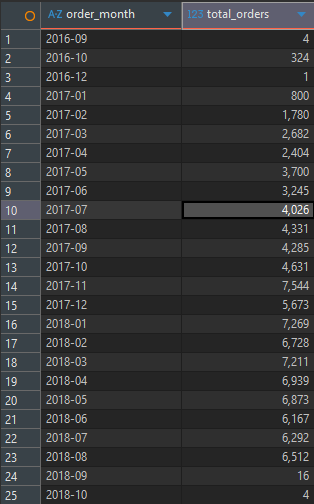

#### 분석 (Analysis)
- 월별 주문량은 2017년부터 전반적으로 증가하는 추세를 보였다.
- 2018년 9~10월은 데이터 수집 기간의 영향으로 주문량이 낮게 집계된 것으로 판단된다.
#### 가설 (Hypothesis)

- 특정 계절, 시기, 이벤트 등이 주문량 증가에 영향을 미쳤을 가능성이 있다.

### 6.2 월별 매출 분석 (Monthly Sales Trend)

#### SQL Query

```sql
SELECT
    SUBSTR(o.order_purchase_timestamp, 1, 7) AS order_month,
    SUM(oi.price) AS total_sales
FROM orders o
JOIN order_items oi
ON o.order_id = oi.order_id
GROUP BY order_month
ORDER BY order_month;
```

#### 결과 (Result)
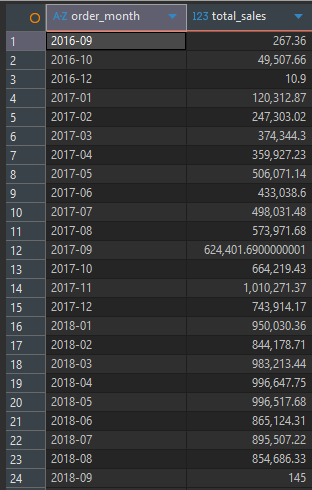

#### 분석 (Analysis)
- 월별 매출은 2017년 하반기부터 증가하는 추세를 보였으며, 2018년에도 높은 매출 수준을 유지하였다.
- Data Quality에서 확인한 데이터 수집 기간의 영향으로 2018년 9~10월의 매출은 실제보다 낮게 집계된 것으로 판단된다.

#### 가설 (Hypothesis)
- 특정 시기의 이벤트나 프로모션이 매출 증가에 영향을 미쳤을 가능성이 있다.
- 매출 증가 원인을 확인하기 위해 추가적인 데이터 분석이 필요하다.

### 6.3 주문 상태 분석 (Order Status Analysis)

#### SQL Query

```sql
SELECT
    order_status,
    COUNT(*) AS order_count
FROM orders
GROUP BY order_status
ORDER BY order_count DESC;
```

#### 결과 (Result)
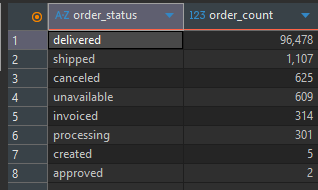

#### 분석 (Analysis)
- `delivered` 상태의 주문이 대부분을 차지하였으며, `canceled`와 `unavailable` 주문은 상대적으로 적은 비중을 차지하였다.

#### 가설 (Hypothesis)
- `canceled`와 `unavailable` 주문이 발생한 원인을 파악하기 위해 추가적인 데이터 분석이 필요하다.

### 6.4 요일별 주문 분석 (Weekday Order Analysis)

#### SQL Query

```sql
SELECT
    CASE
        WHEN strftime('%w', order_purchase_timestamp) = '0' THEN 'Sunday'
        WHEN strftime('%w', order_purchase_timestamp) = '1' THEN 'Monday'
        WHEN strftime('%w', order_purchase_timestamp) = '2' THEN 'Tuesday'
        WHEN strftime('%w', order_purchase_timestamp) = '3' THEN 'Wednesday'
        WHEN strftime('%w', order_purchase_timestamp) = '4' THEN 'Thursday'
        WHEN strftime('%w', order_purchase_timestamp) = '5' THEN 'Friday'
        WHEN strftime('%w', order_purchase_timestamp) = '6' THEN 'Saturday'
    END AS weekday,
    COUNT(*) AS total_orders
FROM orders
GROUP BY weekday
ORDER BY COUNT(*) DESC;

```

#### 결과 (Result)
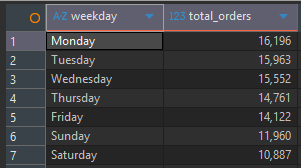

#### 분석 (Analysis)
- 평일의 주문량이 주말보다 높은 경향을 확인하였다.
- 월요일의 주문 건수가 가장 많고 토요일의 주문 건수가 가장 적게 나타났다.

#### 가설 (Hypothesis)
- 평일과 주말의 소비 패턴 차이가 주문량에 영향을 미쳤을 가능성이 있다.

### 6.5 고객 구매 분석 (Customer Purchase Analysis)

#### 6.5.1 `customer_id` 기준 주문 횟수 분석

##### SQL Query

```SQL
SELECT
    customer_id,
    COUNT(order_id) AS total_orders
FROM orders
GROUP BY customer_id
ORDER BY total_orders DESC
LIMIT 10;
```

##### 결과 (Result)
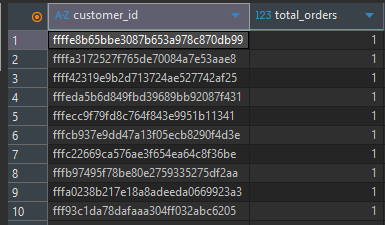

##### 분석 (Analysis)
- customer_id 기준으로 주문 횟수를 집계한 결과 대부분의 고객이 1회의 주문만 기록하였다.
- 실제 고객의 재구매 여부를 분석하기에는 적합하지 않았다.

##### 가설 (Hypothesis)
- 실제 고객의 구매 패턴을 분석하기 위해 customer_unique_id를 기준으로 추가 분석이 필요하다.

#### 6.5.2 `customer_unique_id` 기준 주문 횟수 분석

##### SQL Query

```SQL
SELECT
    c.customer_unique_id,
    COUNT(o.order_id) AS total_orders
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
GROUP BY c.customer_unique_id
ORDER BY total_orders DESC
LIMIT 10;
```

##### 결과 (Result)
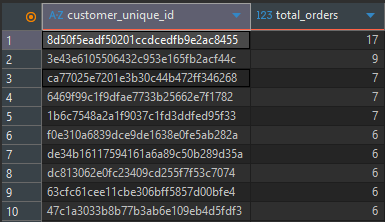

#### 분석 (Analysis)

- customer_unique_id를 기준으로 집계한 결과 일부 고객은 여러 차례 주문한 것으로 확인되었다.
- 가장 많은 고객은 총 17회의 주문을 기록하였다.

#### 가설 (Hypothesis)

- 재구매 고객의 구매 패턴을 분석하기 위해 주문 시기, 상품 카테고리 등에 대한 추가 분석이 필요하다.

### 6.6 상품별 판매량 분석 (Product Sales Analysis)

#### SQL Query

```SQL
SELECT
    p.product_id,
    COUNT(*) AS total_sales
FROM products p
JOIN order_items oi
ON oi.product_id = p.product_id
GROUP BY p.product_id
ORDER BY total_sales DESC
LIMIT 15;
```

#### 결과 (Result)
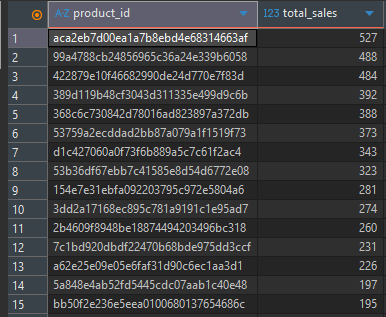

#### 분석 (Analysis)
- 가장 많이 판매된 상품은 총 527회 판매되었다.
- 판매량 상위 상품이 존재함을 확인하였다.

#### 가설 (Hypothesis)
- 판매량이 높은 원인을 확인하기 위해 상품 카테고리와 가격에 대한 추가 분석이 필요하다.

### 6.7 상품 카테고리별 판매량 분석 (Product Category Sales Analysis)

#### SQL Query

```SQL
SELECT
    p.product_category_name ,
    COUNT(*) AS total_sales
FROM products p
JOIN order_items oi
ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY total_sales DESC
LIMIT 10;
```

#### 결과 (Result)
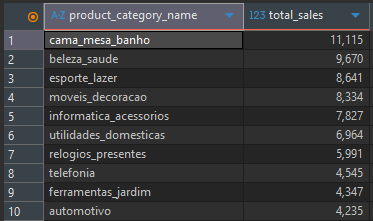

#### 분석 (Analysis)
- 생활용품(cama_mesa_banho) 카테고리가 가장 높은 판매량을 기록하였다.
- 생활용품 외에도 뷰티·건강(beleza_saude), 스포츠(esporte_lazer) 등 다양한 카테고리가 상위권에 포함되었다.

#### 가설 (Hypothesis)
- 카테고리별 소비 패턴의 차이가 판매량에 영향을 미쳤을 가능성이 있다.

### 6.8 평균 배송 기간 분석 (Average Delivery Time)

#### SQL Query

```SQL
SELECT
    AVG(
        julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp)
    ) AS avg_delivery_days
FROM orders;
```

#### 결과 (Result)
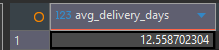

#### 분석 (Analysis)
- 평균적으로 배송이 완료되는데 약 13일 정도 소요되는 것으로 확인되었다.

#### 가설 (Hypothesis)
- 배송 기간은 판매자, 지역, 상품 종류 등의 요인에 따라 차이가 발생했을 가능성이 있다.

### 6.9 배송 지연 분석 (Delayed Delivery Analysis)

#### SQL Query

```SQL
SELECT
	CASE
    	WHEN order_delivered_customer_date > order_estimated_delivery_date
	    THEN 'LATE'
	    ELSE 'ON TIME'
	END AS delivery_status,
	COUNT(*) AS total_orders		
FROM orders
WHERE order_delivered_customer_date IS NOT NULL
GROUP BY delivery_status
ORDER BY delivery_status;
```

#### 결과 (Result)
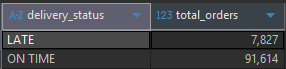

#### 분석 (Analysis)
- 대부분의 주문은 예정된 배송 일정 내에 완료되었다.
- 지연 배송은 총 7,827건으로 확인되었다.

#### 가설 (Hypothesis)
- 판매자, 지역, 물류 환경 등의 차이가 배송 일정에 영향을 미쳤을 가능성이 있다.

### 6.10 평균 주문 금액 (Average Order Value)

#### SQL Query

```SQL
SELECT
    ROUND(AVG(order_total), 2) AS avg_order_value
FROM (
    SELECT
        order_id,
        SUM(price) AS order_total
    FROM order_items
    GROUP BY order_id
) AS order_summary;
```

#### 결과 (Result)
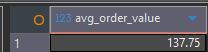

#### 분석 (Analysis)
- 주문 1건당 평균 구매 금액은 약 137.76으로 나타났다.

#### 가설 (Hypothesis)
- 상품의 종류와 구매 수량이 주문 금액에 영향을 미쳤을 가능성이 있다.

#### SQL Note
> 주문별 구매 금액을 먼저 집계한 후, 서브쿼리를 활용하여 평균 주문 금액(Average Order Value)을 계산하였다.

### 6.11 상품 카테고리별 매출 분석 (Sales by Product Category)

#### SQL Query

```SQL
SELECT
    p.product_category_name,
    ROUND(SUM(oi.price), 2) AS total_sales
FROM order_items oi
JOIN products p
ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY total_sales DESC
LIMIT 10;
```

#### 결과 (Result)
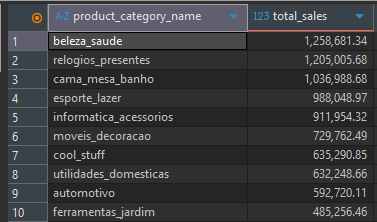

#### 분석 (Analysis)
- 뷰티·건강(beleza_saude) 카테고리가 가장 높은 매출을 기록하였으며, 시계(relogios_presentes)와 생활용품(cama_mesa_banho)이 뒤를 이었다.
- 판매량과 매출의 상위 카테고리가 다르게 나타나, 판매량만으로는 매출을 설명하기 어려운 것을 확인하였다.

#### 가설 (Hypothesis)
- 카테고리별 상품 가격의 차이가 매출 순위에 영향을 미쳤을 가능성이 있다.

### 6.12 월별 평균 주문 금액 분석 (Monthly Average Order Value)

#### SQL Query

```SQL
SELECT
    monthly_total.order_month,
    ROUND(AVG(monthly_total.order_total), 2) AS avg_order_value
FROM (
    SELECT
        SUBSTR(o.order_purchase_timestamp, 1, 7) AS order_month,
        oi.order_id,
        SUM(oi.price) AS order_total
    FROM orders o
    JOIN order_items oi
    ON o.order_id = oi.order_id
    GROUP BY order_month, oi.order_id
) AS monthly_total
GROUP BY monthly_total.order_month
ORDER BY monthly_total.order_month;
```

#### 결과 (Result)
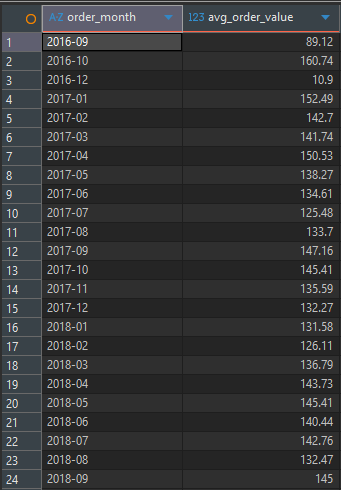

#### 분석 (Analysis)
- 월별 평균 주문 금액은 대부분 120~150 수준에서 비교적 일정하게 유지되었다.
- 기간에 따른 평균 주문 금액의 변동은 크지 않은 것으로 확인되었다.

#### 가설 (Hypothesis)
- 평균 주문 금액은 큰 변화가 없었으며, 월별 매출 변화는 다른 요인의 영향을 받았을 가능성이 있다.

### 6.13 재구매 고객 분석 (Repeat Customer Analysis)

#### SQL Query

```SQL
SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN total_orders >= 2 THEN 1 ELSE 0 END) AS repeat_customers,
    ROUND(
        SUM(CASE WHEN total_orders >= 2 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS repeat_customer_rate
FROM (
    SELECT
        c.customer_unique_id,
        COUNT(*) AS total_orders
    FROM customers c
    JOIN orders o
    ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
) AS customer_order_summary;
```

#### 결과 (Result)
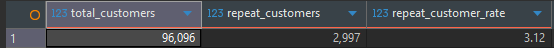

#### 분석 (Analysis)
- 대부분의 고객은 1회 구매에 그치는 것으로 나타났으며, 전체 고객 중 약 3.12%만이 2회 이상 주문한 재구매 고객으로 확인되었다.

#### 가설 (Hypothesis)
- 고객 만족도, 프로모션, 상품 구성 등이 재구매율에 영향을 미쳤을 가능성이 있다.

### 7. Business Insights

- 월별 주문량과 매출은 전반적으로 증가하는 추세를 보였다.
- 판매량과 매출의 상위 카테고리가 다르게 나타나, 판매량만으로는 매출을 설명하기 어려운 것을 확인하였다.
- 생활용품(cama_mesa_banho) 카테고리가 가장 높은 판매량을 기록한 반면, 뷰티·건강(beleza_saude) 카테고리가 가장 높은 매출을 기록하였다.
- 대부분의 주문은 예정된 배송일 이전 또는 예정일에 배송이 완료되어 배송 서비스가 전반적으로 안정적인 수준을 유지하였다.
- 평균 주문 금액(Average Order Value)은 약 137.76으로 확인되었으며, 월별 평균 주문 금액은 큰 변동 없이 유지되었다.
- 전체 고객 중 약 3.12%만이 재구매 고객으로 확인되어 고객 유지(Customer Retention) 측면에서 개선 가능성이 있음을 확인하였다.

## 8. Conclusion

이번 프로젝트에서는 SQL을 활용하여 주문, 고객, 상품, 배송 데이터를 분석하였다.

데이터 품질을 확인한 후 주문 추이, 매출, 고객 구매 패턴, 상품 판매량, 배송 현황 등을 분석하였으며, 이를 통해 데이터의 전반적인 특성과 주요 비즈니스 지표를 확인할 수 있었다.

또한 판매량과 매출의 카테고리 순위가 다르게 나타나 상품 가격이 매출에 영향을 미칠 수 있음을 확인하였으며, 전체 고객 중 약 3.12%만이 재구매 고객으로 나타나 고객 유지 측면에서 개선 가능성이 있음을 확인하였다.

향후에는 고객 세분화(RFM), 지역별 배송 분석, 고객별 구매 행동 분석 등을 추가하여 더욱 다양한 비즈니스 인사이트를 도출할 수 있을 것으로 기대된다.

### Learned

이번 프로젝트를 통해 SQL의 JOIN, GROUP BY, CASE WHEN, Subquery 등을 활용한 데이터 분석 과정을 경험하였다.

특히 데이터 구조를 이해하고, 적절한 집계 기준을 설정하여 원하는 결과를 도출하는 과정을 학습할 수 있었다.